In [ ]:
# Log Returns and Stationarity

This notebook computes log returns from price data and tests for stationarity
using the Augmented Dickey–Fuller test.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [7]:
price_data = pd.read_csv("../data/prices.csv", index_col=0, parse_dates=True)
price_data.head()



,AAPL,MSFT
Date,,
2020-01-02,72.468277,152.505661
2020-01-03,71.763733,150.606735
2020-01-06,72.335556,150.995987
2020-01-07,71.995338,149.619263
2020-01-08,73.153503,152.002457


In [9]:
# Compute Log returns

returns = np.log(price_data).diff().dropna()
returns.head()

,AAPL,MSFT
Date,,
2020-01-03,-0.009770,-0.012530
2020-01-06,0.007937,0.002581
2020-01-07,-0.004714,-0.009159
2020-01-08,0.015959,0.015803
2020-01-09,0.021018,0.012416


In [12]:
# Showing summary statistics of data
returns.describe()


,AAPL,MSFT
count,1005.000000,1005.000000
mean,0.000963,0.000883
std,0.021137,0.020555
min,-0.137708,-0.159453
25%,-0.009169,-0.009492
50%,0.000988,0.000978
75%,0.012663,0.011953
max,0.113157,0.132929


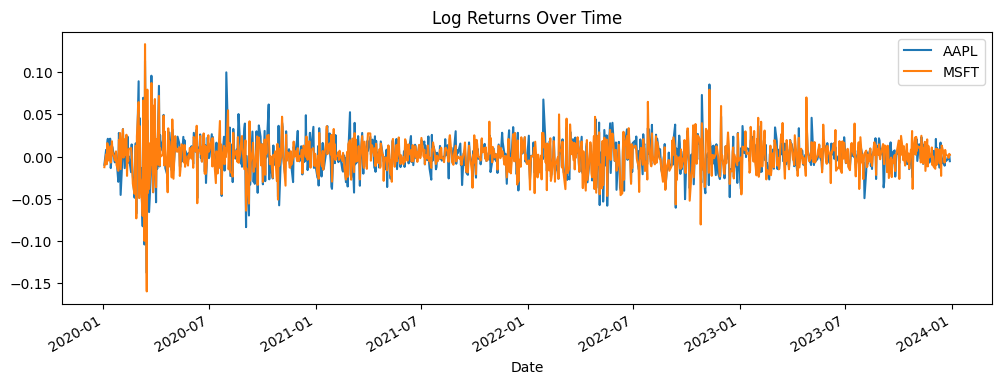

In [15]:
# Plot graph of Log returns over time
returns.plot(figsize=(12, 4))
plt.title("Log Returns Over Time")
plt.show()


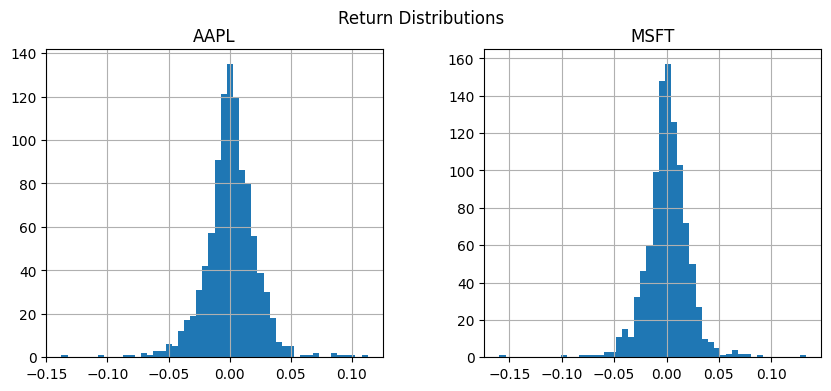

In [21]:
# Plot a histogram
returns.hist(bins=50, figsize=(10, 4))
plt.suptitle("Return Distributions")
plt.show()


 ### What does a histogram show?
 - The centre of the histogram (usually near 0) will show the typical reutrn, ie if it is shifted to right of 0, stock has had a postive average return over the sample period, likewise for left (negative)
 - The spread of the histogram shows how volatile the stock is (ie a wide, flat histogram shows high volatility (as more day-to-day swings) and a narrow, peaked histogram shows low volatility (more stable returns))
 - The skewness of the histogram can show if any large gains or losses (right skewed = occasional large gains, left skewed = occasional large losses)
 - Kurtosis : compared to a normal distrubution, Fat tails show extreme returns that occur more than predicted, but higher kurtosis can imply higher crash risk.


In [24]:
# Run a Augmented Dickey-Fuller test
from statsmodels.tsa.stattools import adfuller

for col in returns.columns:
    stat, pvalue, *_ = adfuller(returns[col])
    print(f"{col}: ADF p-value = {pvalue:.4f}")


AAPL: ADF p-value = 0.0000
MSFT: ADF p-value = 0.0000


### Augmented Dickey-Fuller (ADF) test

The ADF test checks whether a time series is stationary by testing for the presence of a unit root.
A unit root means if a time series is non-stationary and "wanders" over time, with shocks ( a "white noise", have a look at the definition of unit root) accumulating rather than dying out.